In [1]:
library(tidyverse)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.6     ✔ purrr   0.3.4
✔ tibble  3.1.7     ✔ dplyr   1.0.7
✔ tidyr   1.1.4     ✔ stringr 1.4.0
✔ readr   2.0.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()



In [12]:
decv_ra <- read.csv("ace_pilot_rare_vars.csv")

In [7]:
head(decv_ra)

,X,variant,zeros,ones
,<int>,<chr>,<int>,<int>
1,1,chr1:1041678:CGCTCCGGCCAGTGCCAGGGTCGAGGTGAGCGGCTCCCCCGGGGGAGG:C,0,0
2,2,chr1:11847267:C:T,0,1
3,3,chr1:13342921:T:C,0,0
4,4,chr1:13342933:G:T,0,0
5,5,chr1:13420931:C:T,0,1
6,6,chr1:23971953:C:A,0,0


In [14]:
decv_ra$chrom <- sub("chr(\\d+):.*", "\\1", decv_ra$variant)

In [15]:
head(decv_ra)

,X,variant,zeros,ones,chrom
,<int>,<chr>,<int>,<int>,<chr>
1,1,chr1:1041678:CGCTCCGGCCAGTGCCAGGGTCGAGGTGAGCGGCTCCCCCGGGGGAGG:C,0,0,1
2,2,chr1:11847267:C:T,0,1,1
3,3,chr1:13342921:T:C,0,0,1
4,4,chr1:13342933:G:T,0,0,1
5,5,chr1:13420931:C:T,0,1,1
6,6,chr1:23971953:C:A,0,0,1


In [16]:
table(decv_ra$chrom)


 1 10 11 12 13 14 15 16 17 18 19  2 20 21 22  3  4  5  6  7  8  9 
43 16 30 29  8 33 14 16 31  5 32 30 10  8 18 23 19 17 25 19 19 20 

In [18]:
summary_df <- decv_ra %>%
  group_by(chrom) %>%
  summarize(zero_count = sum(ones == 0),
            one_count = sum(ones == 1))

In [19]:
summary_df

chrom,zero_count,one_count
<chr>,<int>,<int>
1,27,16
10,9,7
11,13,17
12,16,12
13,4,4
14,24,9
15,4,10
16,7,9
17,17,14


In [21]:
colnames(summary_df) <- c("chrom", "AFR", "EUR")

ERROR while rich displaying an object: Error in factor(ones): object 'ones' not found

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
7. repr::mime2repr[[mime]](obj)
8. repr_text.default(obj)
9. paste(capture

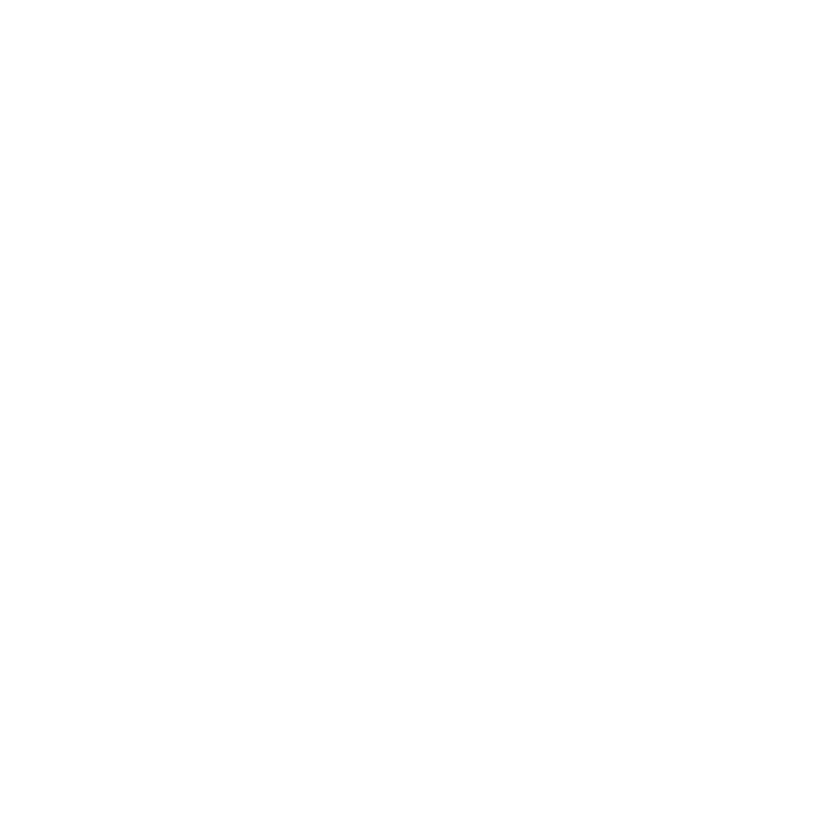

In [20]:
ggplot(summary_df, aes(x = factor(chrom), y = mean, fill = Glass, colour = Glass)) + 
  geom_bar(stat = "identity", position = "dodge")